In [61]:
%load_ext autoreload
%autoreload 2
import main
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

In [18]:
rho = 1
d_list = [100, 200, 400, 800, 1600]
num_runs = 10
num_epochs = 50
sigma2 = 0.01

## Figuring order of quantities empirically

We must find the size of some terms in order to determine $\gamma(d)$

In [33]:
for d in d_list:
    print(main.compute_first_term(d, d, 1/d * np.eye(d), sigma2, 1) * d)
    

0.7813840978608313
0.9231702676902459
1.032035259240807
0.9486467185752723
0.959619626790926


This suggests that $|| \nabla \hat{R}(\theta) ||^2$ grows in $O(1/d)$

In [64]:
for d in d_list:
    print(main.compute_second_term(d, d, 1/d * np.eye(d), sigma2, 1) * d**2)

1.0776716839829736
0.9148245348248842
1.4948642463637056
1.3304929555651164
1.3157051937245394


This suggests that $ \nabla \hat{R} (\theta_{t-1})^T H \nabla \hat{R} (\theta_{t-1}) $ grows in $O(1/d^2)$

In [ ]:
for d in d_list:
    print(main.compute_third_term_sgd(d, d, 1/d * np.eye(d), sigma2, 1) * d**3)

1.8319693272058972
2.601682484609929
1.840812129392928
2.0481747090108127
2.142048180092543


This suggests that $tr \{H Var (g_t | \theta_{t-1}) \}$ grows in $O(1/d^3)$ for SGD

In [ ]:
for d in d_list:
    print(main.compute_third_term_batch(d, d, 1/d * np.eye(d), d, sigma2, 1) * d**2 )

0.027986269487681324
0.021725444143672563
0.014094895567948892


## Experiment 1 : Figuring out scaling on $\gamma$ in small batch SGD

### Without optimizing for the absolute cst

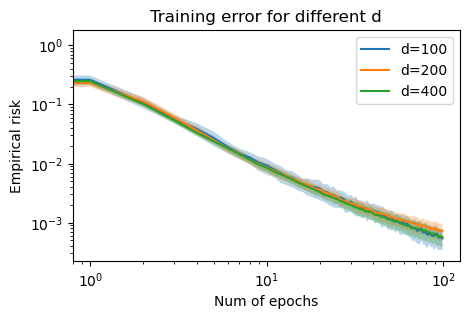

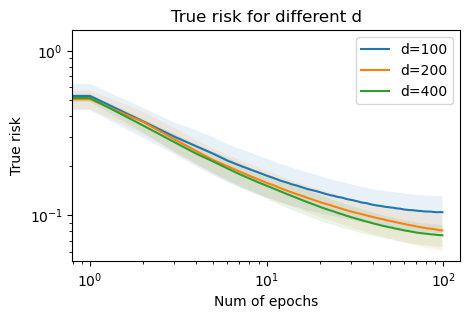

In [12]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d)) 

### Setting the absolute constant to $ \frac{1}{\lambda_{max} (A^T A)} $

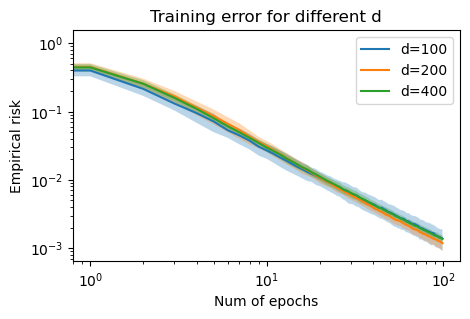

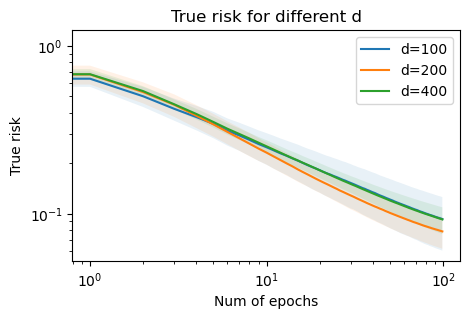

In [120]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d), step_type="max") 

### Setting the absolute constant to $ \frac{1}{\lambda_{avg} (A^T A)} $

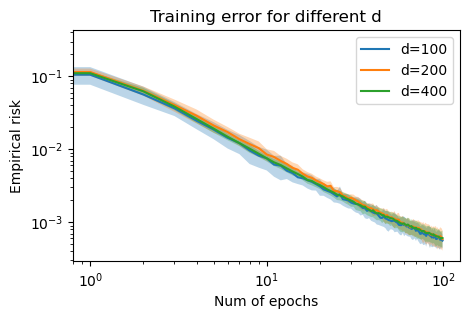

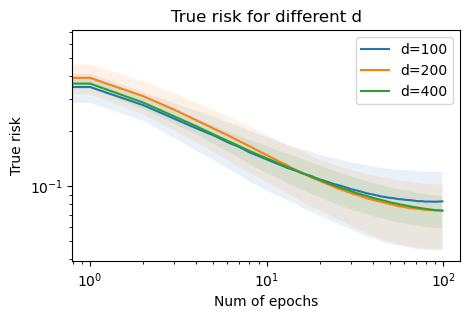

In [5]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=lambda d:np.eye(d), step_type="avg")

### Different covariance structures

In [14]:
cov_structures = {
    "identity": lambda d: np.eye(d),
    "diag_decreasing": lambda d: np.diag(np.linspace(1, 0.1, d)),
    "diag_increasing": lambda d: np.diag(np.linspace(0.1, 2, d)),
    "toeplitz": lambda d: np.array([[0.9**abs(i-j) for j in range(d)] for i in range(d)]),
    "low_rank": lambda d: (np.random.randn(d, 5) @ np.random.randn(5, d))
}

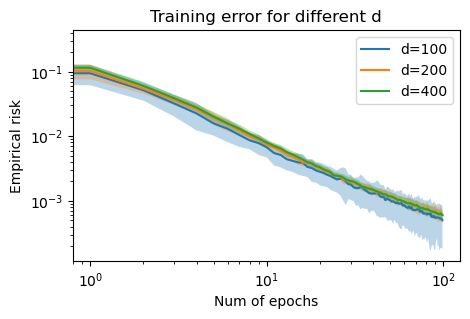

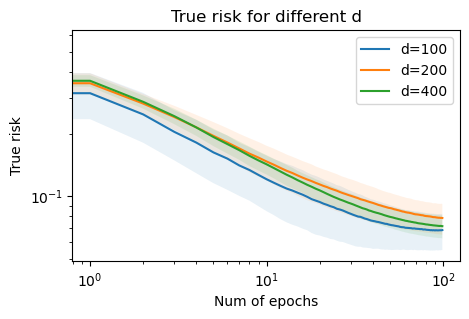

In [12]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="mean") 

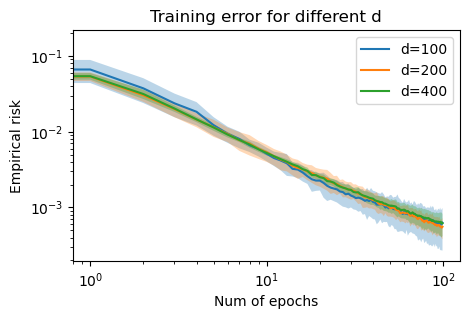

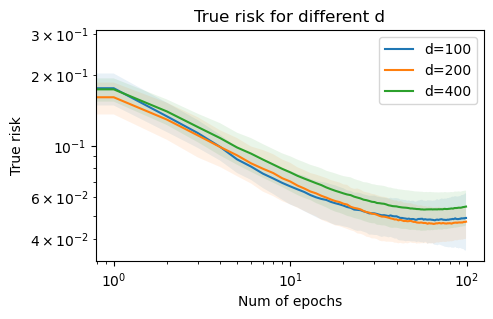

In [8]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["diag_decreasing"], step_type="avg") 

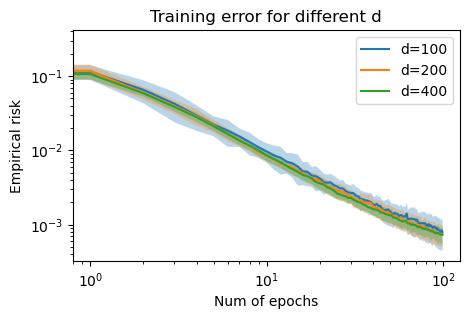

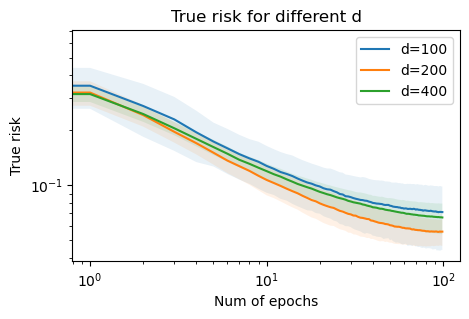

In [9]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["diag_increasing"], step_type="avg") 

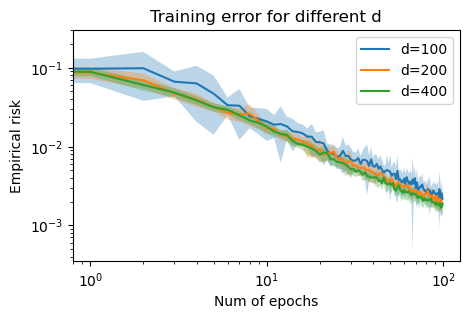

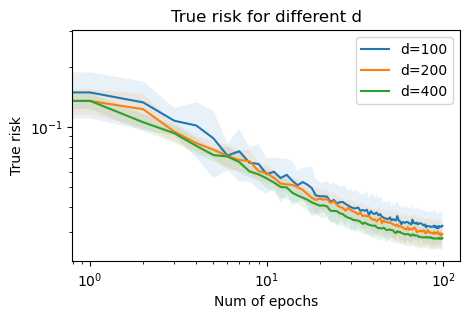

In [10]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.run_sgd, gamma=lambda d:d, sigma_hat=cov_structures["toeplitz"], step_type="avg") 

## Experiment 2 : Effect of randomness in SGD

### Single shuffle sgd

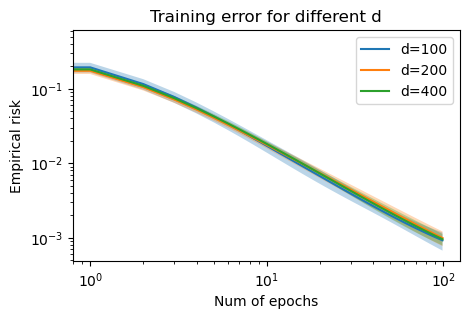

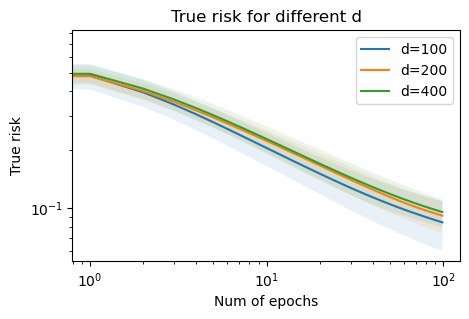

In [51]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.single_suffle_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max") 

### Multiple shuffle sgd

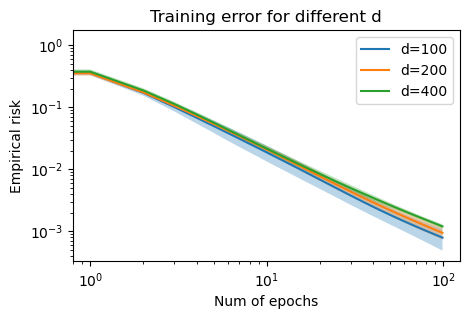

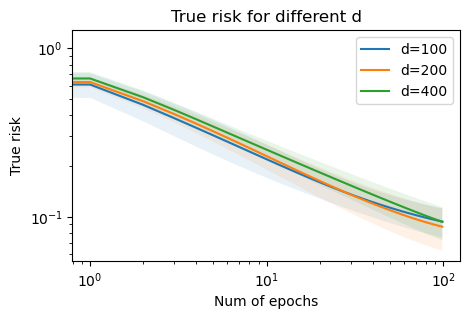

In [131]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.multiple_suffle_sgd, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max") 

## Experiment 3 : SGD with momentum

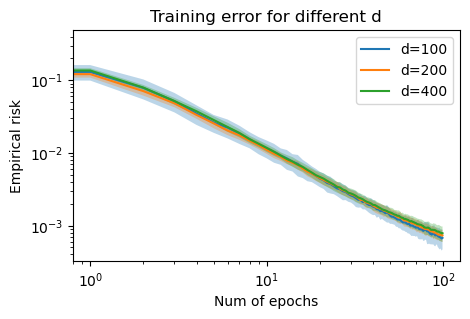

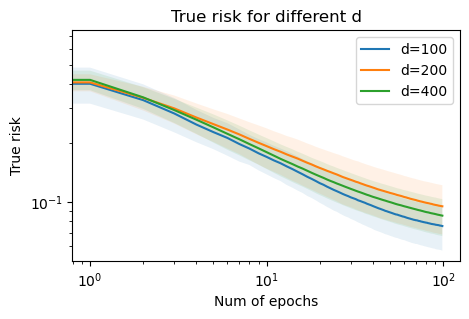

In [46]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_momentum_fixed_delta, gamma=lambda d:d, sigma_hat=cov_structures["identity"], step_type="max")

## Experiment 4 : Small vs large batch sizes

### Full batch $ ( \left |B| = n \right )$ 

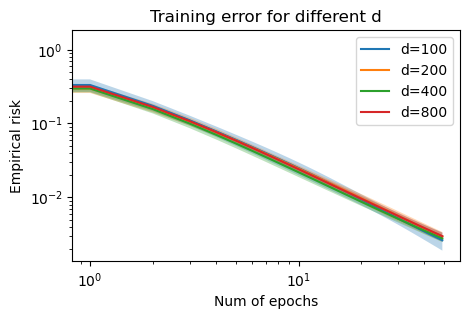

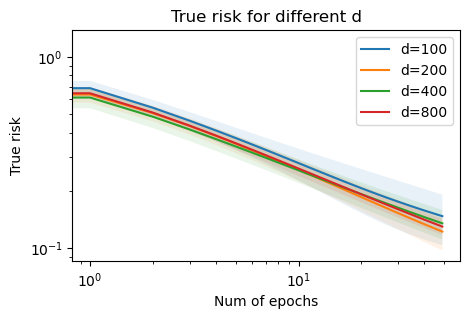

In [49]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**2, sigma_hat=cov_structures["identity"], batch_size=lambda n:int(n), step_type= "max")

### Half batch $ ( \left |B| = n/2 \right )$ 

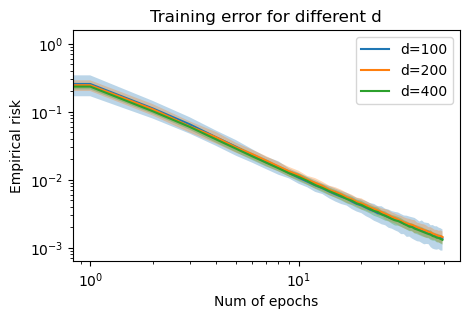

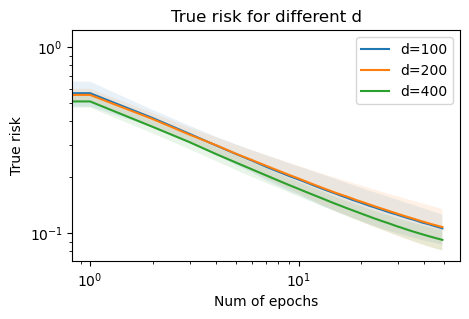

In [35]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**2, sigma_hat=cov_structures["identity"], step_type="max", batch_size=lambda n:int(n/2))

### Small batch $ ( \left |B| = n/5 \right )$ 

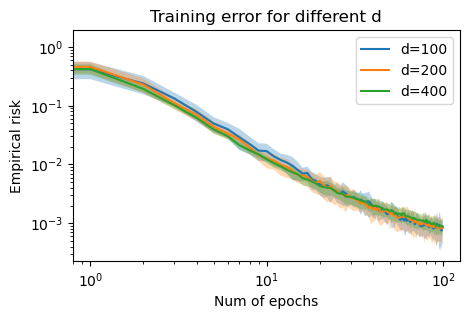

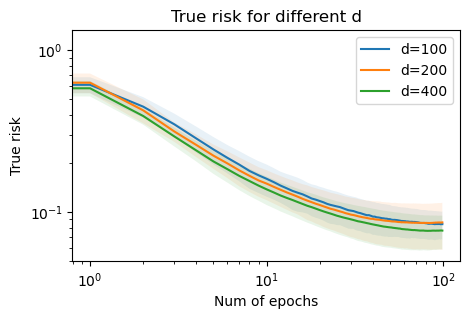

In [121]:
main.plot_risk(d_list, rho, num_runs, num_epochs, sigma2, main.sgd_batch, gamma=lambda d:d**2, sigma_hat=cov_structures["identity"], step_type="max", batch_size=lambda n:int(n/5))